### imports

In [1]:
import joblib
import os.path as op

import scipy
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from src.load_dataset import (create_paired_dataset, repeat_pair_images, probabilistic_binary_labels, label_dict, supervised_dict, supervised_labels, 
transition_likelihoods, flatten, transition_target, img_preproc, autoregressive_target, sharpened_probabilistic_binary_labels, paired_augment)
from src.training import (PredPriorLoss, FFLossWithThreshold, model_fit, model_fit_layers, model_do_not_fit)
from src.visualization import plot_image_series, plot_training_history, plot_rdm

2026-09-10 16:23:51.042456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-10 16:23:51.057212: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-10 16:23:51.061865: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-10 16:23:51.072789: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### define paths and parameters

In [2]:
# Define the stimulus data directory.
data_dir = "/scratch/guetlid95/datasets/mcdermott_2024/stimuli_2"

# Define paths for the test stimuli.
test_leading_dir = op.join(data_dir, "test", "leading")
test_trailing_dir = op.join(data_dir, "test", "trailing")

# Define the directory containing the trained models.
results_dir = "/scratch/guetlid95/datasets/mcdermott_2024/models_isi"

# Define model and input parameters.
batch_size = 10000
n_steps = 15
image_size = (40, 40)

# Print the label mapping.
print(label_dict)

{('barn', 'church'): 0.75, ('barn', 'conference_room'): 0.25, ('barn', 'castle'): 0.0, ('barn', 'forest'): 0.0, ('beach', 'church'): 0.75, ('beach', 'conference_room'): 0.25, ('beach', 'castle'): 0.0, ('beach', 'forest'): 0.0, ('library', 'church'): 0.25, ('library', 'conference_room'): 0.75, ('library', 'castle'): 0.0, ('library', 'forest'): 0.0, ('restaurant', 'church'): 0.25, ('restaurant', 'conference_room'): 0.75, ('restaurant', 'castle'): 0.0, ('restaurant', 'forest'): 0.0, ('cave', 'church'): 0.0, ('cave', 'conference_room'): 0.0, ('cave', 'castle'): 0.5, ('cave', 'forest'): 0.5}


### load image stimuli

2026-09-10 16:24:11.905819: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


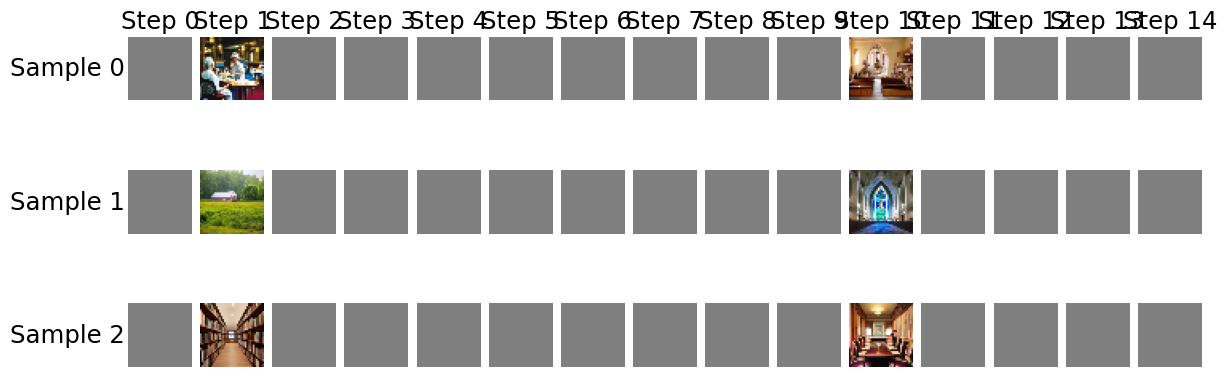

In [3]:
# Define hyperparameters.
n_steps = 15


def repeat_images(x, y, n_steps=n_steps, inter_stim_interval=True):
    if inter_stim_interval:
        x, y = repeat_pair_images(x, y, n_steps // 2)
        flip = n_steps // 15
        isi_shape = tf.concat([[batch_size, 8 * flip], tf.shape(x)[2:]], axis=0)
        isi = tf.fill(isi_shape, tf.constant(0.5, x.dtype))
        x = tf.concat([isi[:, :flip], x[:, :flip], isi, x[:, -flip:], isi[:, :4*flip]], axis=1)
        y_repeated = tf.repeat(y[:, :flip], repeats=10, axis=1)
        y = tf.concat([y_repeated, y[:, -5*flip:]], axis=1)
    else:
        reps = n_steps // 2 if (n_steps % 2 == 0) else (n_steps + 1) // 2
        x, y = repeat_pair_images(x, y, reps)
        if not (n_steps % 2 == 0):  # Uneven number of steps.
            x, y = x[:, :-1], y[:, :-1]
    return x, y


# Create a dictionary containing all possible leading/trailing combinations.
leading_classes, trailing_classes = sorted({k[0] for k in label_dict.keys()}), sorted({k[1] for k in label_dict.keys()})
all_combinations_dict = {(a, b): 1. / len(trailing_classes) for a in leading_classes for b in trailing_classes}

# Create a validation dataset using the specified label mapping.
val_dataset = create_paired_dataset(
    leading_dir=test_leading_dir,
    trailing_dir=test_trailing_dir,
    transition_dict=label_dict,
    batch_size=batch_size,
    image_size=image_size,
    shuffle_buffer_size=250,
)

# Preprocess and repeat one batch of validation images.
for x, y in val_dataset.map(img_preproc).map(repeat_images).take(1):
    pass


# Plot the resulting sample.
plot_image_series(np.reshape(x, [-1, n_steps, image_size[0], image_size[1], 3]),
                  sample_indices=[0, 1, 2], time_indices=np.arange(n_steps), figsize=[12, 4], ylabel_rotation=0)

### save RDMs

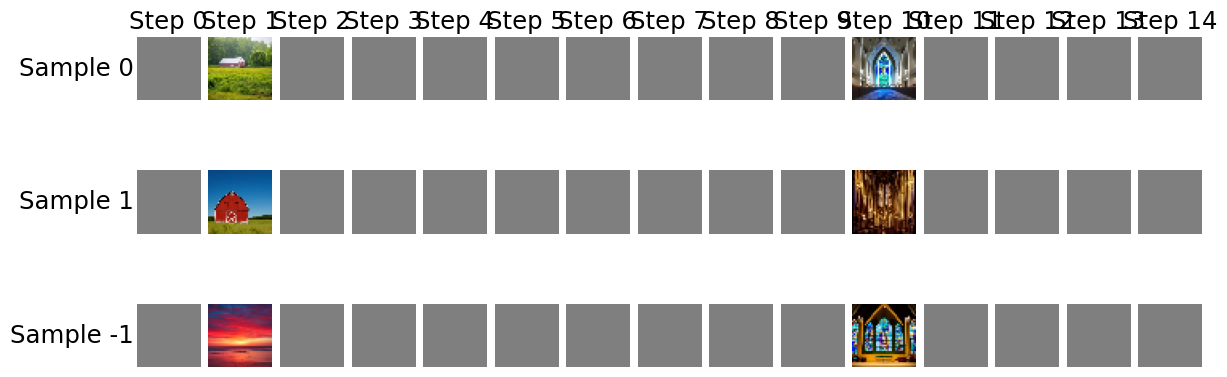

In [5]:
# Translate separate stimuli to combined conditions.
translation_dict = {
    ('barn', 'church'):"valid_church",
    ('barn', 'conference_room'):"invalid_confroom",
    ('beach', 'church'):"valid_church",
    ('beach', 'conference_room'):"invalid_confroom",
    ('library', 'church'):"invalid_church",
    ('library', 'conference_room'):"valid_confroom",
    ('cave', 'castle'):"control_castle",
    ('cave', 'forest'):"control_forest",
    ('restaurant', 'church'):"invalid_church",
    ('restaurant', 'conference_room'):"valid_confroom"
}


def get_rdm(activation_dict):
    """Calculate time-resolved RDMs from ordered activations."""
    activation_df = pd.concat({k: pd.DataFrame(v) for k, v in activation_dict.items()}, names=["category", "step"])

    # Calculate RDMs over time steps.
    activation_df = pd.DataFrame([
        scipy.spatial.distance.pdist(activation_df.xs(t, level='step').values, metric='correlation')
        for t in range(activation_df.index.get_level_values('step').nunique())
    ])
    activation_df.index.name = 'step'
    return activation_df


# Extract the condition keys for each sample.
decode_vec = np.vectorize(lambda b: b.decode('utf-8'))
y_np = y.numpy()
indices = [(i, j) for i, j in zip(decode_vec(y_np[:, 0]), decode_vec(y_np[:, -1]))]

# Group samples by combined condition while preserving the specified condition order.
sorted_data = {}
for key, name in translation_dict.items():
    class_indices = [i for i, val in enumerate(indices) if key == val]

    # Add or append samples to the corresponding category.
    if name not in list(sorted_data.keys()):
        sorted_data[name] = tf.gather(x, class_indices)
    else:
        sorted_data[name] = tf.concat([sorted_data[name], tf.gather(x, class_indices)], axis=0)


# Plot one condition to check the sorted data.
plot_image_series(
    np.reshape(sorted_data['valid_church'], [-1, n_steps, image_size[0], image_size[1], 3]),
    sample_indices=[0, 1, -1],
    time_indices=np.arange(n_steps),
    figsize=[12, 4],
    ylabel_rotation=0
)


for condition in [
    "Supervised",
    "Supervised shuffled",
    "Untrained",
    "Predictive global",
    "Predictive local",
    "Contrastive global",
    "Contrastive local",
]:
    # Load the model.
    model = tf.keras.models.load_model(op.join(results_dir, f"{condition}_final.keras"))

    # Keep the EEG condition order consistent with the RDMs.
    eeg_order_keywords = [
        'valid_church',
        'valid_confroom',
        'invalid_confroom',
        'invalid_church',
        'control_castle',
        'control_forest',
    ]
    activation_dict = {}

    for key in eeg_order_keywords:
        inputs = sorted_data[key]
        layer_activations = []

        # Extract activations from the latent layers.
        for layer in model.layers[:2]:
            inputs = layer(inputs)
            activations = inputs
            layer_activations.append(activations)

        layer_activations = [i.numpy().mean(axis=0) for i in layer_activations]

        # Store the mean activation for each condition.
        activation_dict[key] = layer_activations

    # Create RDMs for each layer and for the concatenated latent representation.
    layer_1_rdms = get_rdm({key:activation_dict[key][0] for key in eeg_order_keywords})
    layer_2_rdms = get_rdm({key:activation_dict[key][1] for key in eeg_order_keywords})
    layer_all_rdms = get_rdm({key:np.concatenate(activation_dict[key], axis=-1) for key in eeg_order_keywords})

    # Save the RDMs.
    layer_1_rdms.to_pickle(op.join(results_dir, condition + "_rdm_valid_invalid_spearman_layer1.pkl"))
    layer_2_rdms.to_pickle(op.join(results_dir, condition + "_rdm_valid_invalid_spearman_layer2.pkl"))
    layer_all_rdms.to_pickle(op.join(results_dir, condition + "_rdm_valid_invalid_spearman_layerall.pkl"))